In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import glob

In [18]:
ImgMoscow_l = cv2.imread('moscow_l.jpeg')
ImgMoscow_l = cv2.cvtColor(ImgMoscow_l, cv2.COLOR_BGR2RGB)

ImgMoscow_l_turn = cv2.imread('moscow_l_turn.jpeg')
ImgMoscow_l_turn = cv2.cvtColor(ImgMoscow_l_turn, cv2.COLOR_BGR2RGB)

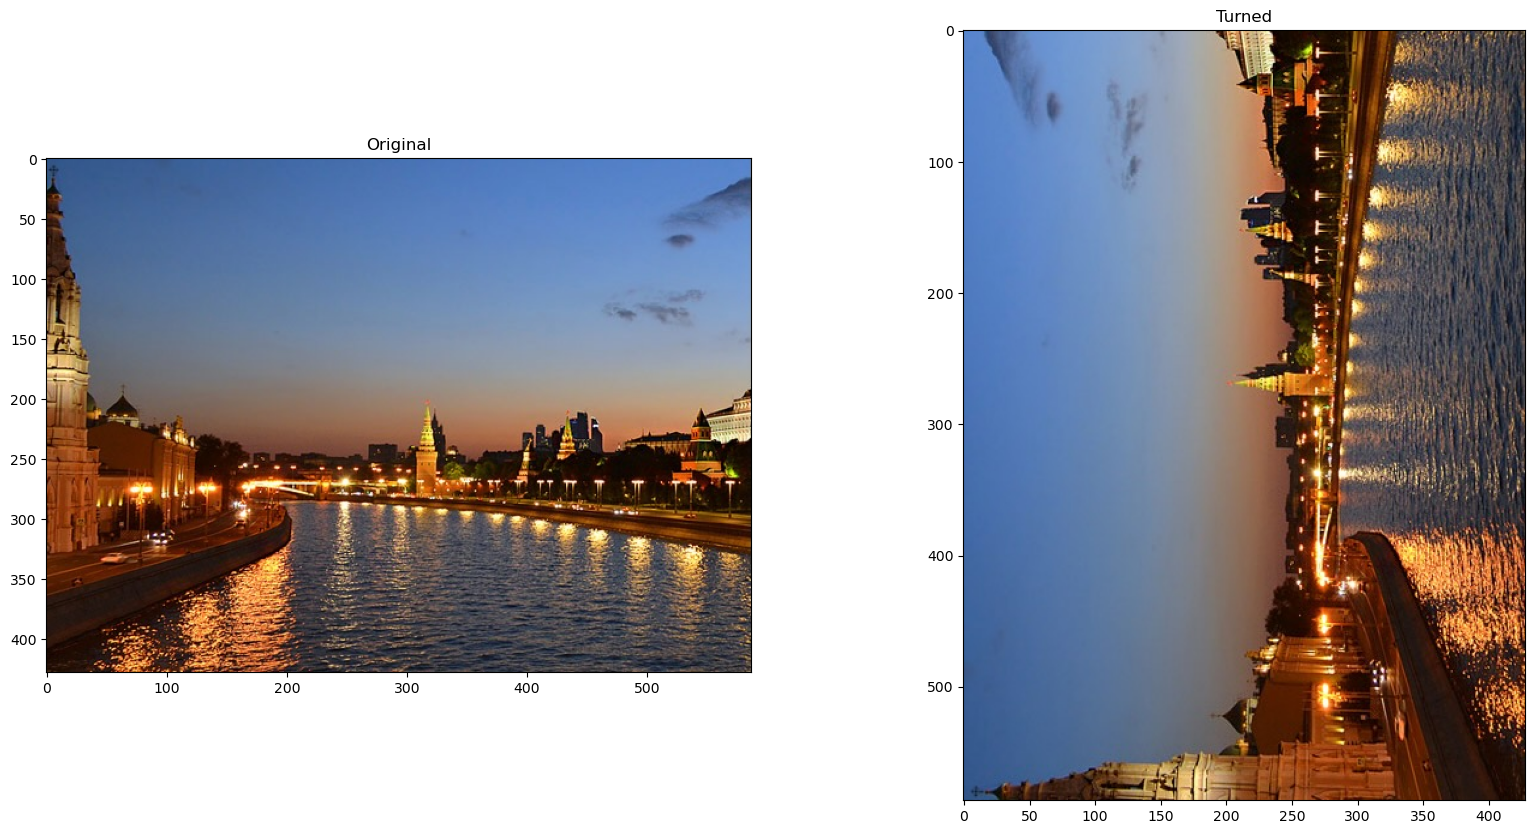

In [19]:
plt.figure(figsize = [20,10])
plt.subplot(121); plt.imshow(ImgMoscow_l); plt.title("Original");
plt.subplot(122); plt.imshow(ImgMoscow_l_turn); plt.title("Turned");

In [20]:
ImgMoscow_l_Gray = cv2.cvtColor(ImgMoscow_l, cv2.COLOR_RGB2GRAY)
ImgMoscow_l_turn_Gray = cv2.cvtColor(ImgMoscow_l_turn, cv2.COLOR_RGB2GRAY)

nMaxFeature = 500000
orb = cv2.ORB_create(nMaxFeature)
keypoints1, descs1 = orb.detectAndCompute(ImgMoscow_l_Gray, None) # keypoint - геометрия, descs - вектор точки
keypoints2, descs2 = orb.detectAndCompute(ImgMoscow_l_turn_Gray, None)

# OrigKey = cv2.drawKeypoints(ImgMoscow_r, keypoints1, outImage=np.array([]), color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
# ToMoveKey = cv2.drawKeypoints(ImgMoscow_r_turn, keypoints2, outImage=np.array([]), color=(255, 0, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

In [21]:
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = matcher.match(descs1, descs2, None)

In [22]:
matches = list(matches)
matches.sort(key = lambda x: x.distance, reverse = False)

# print(len(matches))

nGoodMatches = int(len(matches) * 0.7)
matches = matches[:nGoodMatches]

In [17]:
# imgMatches = cv2.drawMatches(ImgMoscow_r, keypoints1, ImgMoscow_r_turn, keypoints2, matches, None)

# plt.figure(figsize=[18, 15])
# plt.imshow(imgMatches)

In [23]:
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

H, mask = cv2.findHomography(points2, points1, cv2.RANSAC) # RANSAC - оптимальное решение
print(H)

[[ 1.80643816e-03 -1.00006723e+00  5.85333441e+02]
 [ 1.00062076e+00  5.89960725e-04 -1.79412494e-01]
 [ 8.77109031e-08  1.94521991e-06  1.00000000e+00]]


In [26]:
h, w, c = ImgMoscow_l.shape
ImgMoscow_res = cv2.warpPerspective(ImgMoscow_l_turn, H, (w, h))

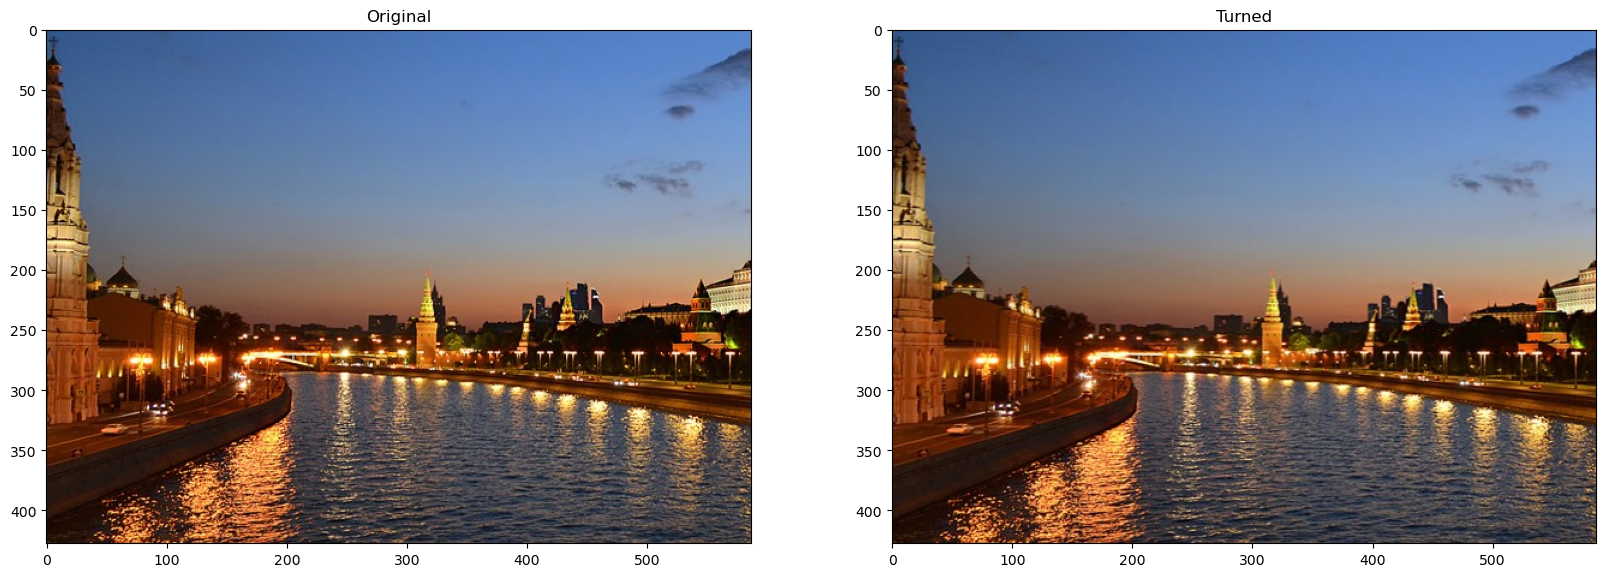

In [27]:
plt.figure(figsize = [20,10])
plt.subplot(121); plt.imshow(ImgMoscow_l); plt.title("Original");
plt.subplot(122); plt.imshow(ImgMoscow_res); plt.title("Turned");

In [29]:
cv2.imwrite("moscow_r_res.png", ImgMoscow_res[:, :, ::-1])

True